
# Download and Plot SGPS Proton Flux Data

Download, read, and plot proton flux from SGPS L2 data.


Import modules



In [1]:
import os
import requests
import netCDF4 as nc
import xarray as xr
import numpy as np
import cftime
import matplotlib.pyplot as plt
from matplotlib import colors, gridspec
import matplotlib.dates as mdates

Download, read, and get relevant data from files



In [2]:
files = [
         "sci_sgps-l2-avg5m_g18_d20251111_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251112_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251113_v3-0-2.nc",
         "sci_sgps-l2-avg5m_g18_d20251114_v3-0-2.nc",
]

url_path = "https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes18/l2/data/sgps-l2-avg5m/2025/11/"

proton_diff_flux_west = []
proton_diff_flux_east = []
proton_int_flux = []
time = []

for filename in files:
    # Download `filename` if it does not exist locally
    if not os.path.exists(filename):
        with open(filename, "wb") as f:
            r = requests.get(url_path + filename)
            f.write(r.content)

    # Load data from file
    sgps_data = nc.Dataset(filename)

    # Get flux data
    proton_diff_flux_west.append(sgps_data['AvgDiffProtonFlux'][:, 0, :])
    proton_diff_flux_east.append(sgps_data['AvgDiffProtonFlux'][:, 1, :])
    proton_int_flux.append(sgps_data['AvgIntProtonFlux'][:])

    # Get timestamps
    # Two different time variable names may have been used
    try:
        time.append(sgps_data['L2_SciData_TimeStamp'][:])
    except IndexError:
        time.append(sgps_data['time'][:])

# Convert list of arrays into single array
proton_diff_flux_west = np.ma.concatenate(proton_diff_flux_west)
proton_diff_flux_east = np.ma.concatenate(proton_diff_flux_east)
proton_int_flux = np.ma.concatenate(proton_int_flux)
time = np.ma.concatenate(time)

# replace zeros with nans
proton_diff_flux_west = np.where(proton_diff_flux_west < 1.e-12, np.nan, proton_diff_flux_west)
proton_diff_flux_east = np.where(proton_diff_flux_east < 1.e-12, np.nan, proton_diff_flux_east)
proton_int_flux = np.where(proton_int_flux < 1.e-12, np.nan, proton_int_flux)

# Convert J2000 time to python datetime
time = cftime.num2pydate(time[:], sgps_data['time'].units)

Plot SGPS flux



(3563,)
(3563,)


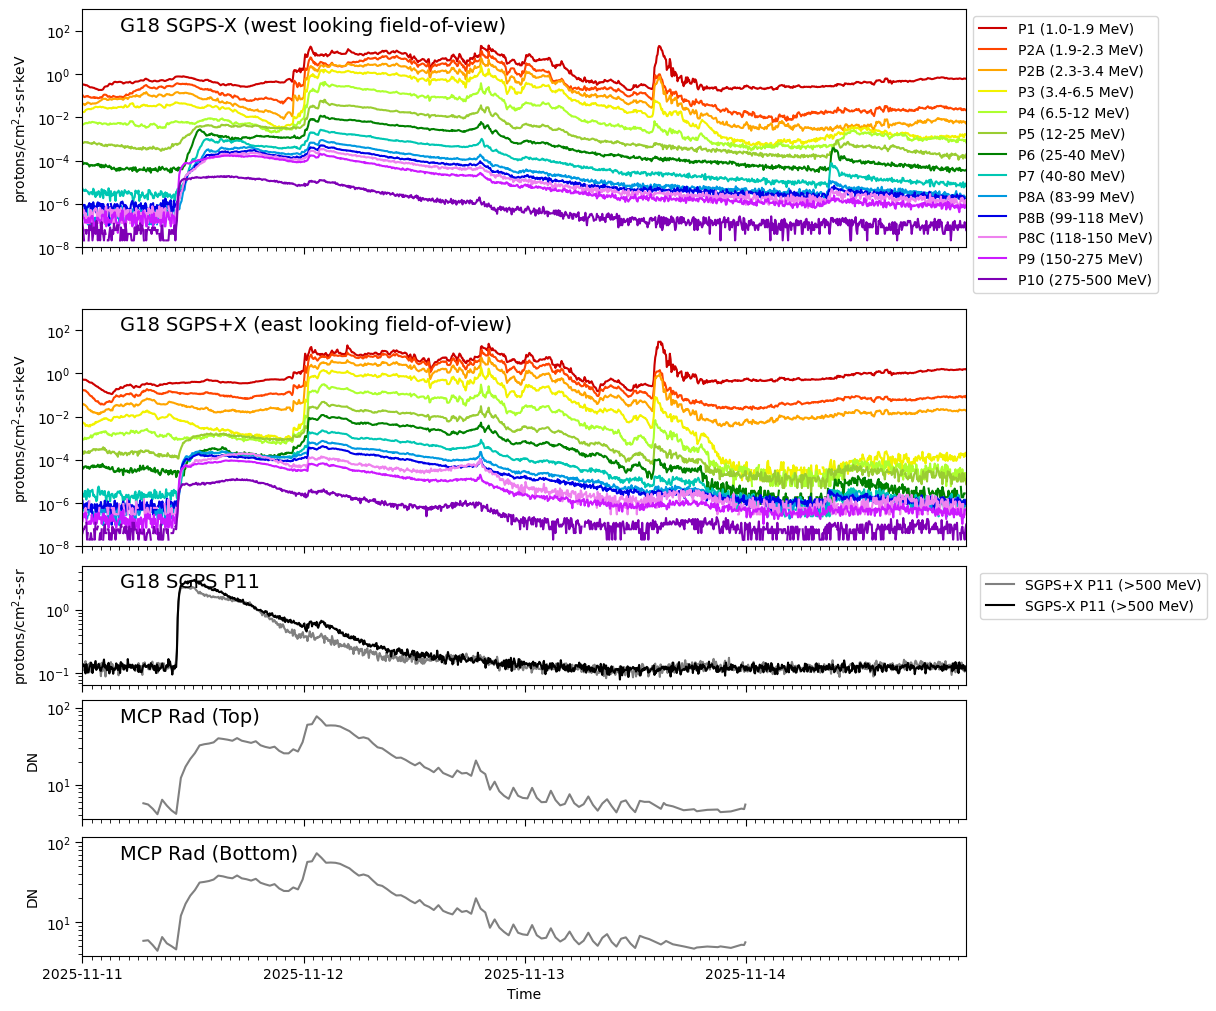

In [3]:
plt.figure(1, figsize=[12, 10], layout='constrained')
gridspec.GridSpec(7, 1)

# Plot differential flux
NUM_DIFF_CHANNELS = 13

chan_colors = [[.8, 0., 0.], colors.to_rgba('orangered')[0:3], colors.to_rgba('orange')[0:3],
               [.95, .95, .0], colors.to_rgba('greenyellow')[0:3], colors.to_rgba('yellowgreen')[0:3],
               colors.to_rgba('green')[0:3], [0., .78, .7], [0., .6, .88], [0., 0., .9],
               colors.to_rgba('violet')[0:3], [0.8, .1, 1.0], [0.49411765, 0., 0.70980392]]

chan_labels = ['P1 (1.0-1.9 MeV)', 'P2A (1.9-2.3 MeV)', 'P2B (2.3-3.4 MeV)', 'P3 (3.4-6.5 MeV)',
               'P4 (6.5-12 MeV)', 'P5 (12-25 MeV)', 'P6 (25-40 MeV)', 'P7 (40-80 MeV)',
               'P8A (83-99 MeV)', 'P8B (99-118 MeV)', 'P8C (118-150 MeV)', 'P9 (150-275 MeV)',
               'P10 (275-500 MeV)']

# SGPS-X (west)
ax1 = plt.subplot2grid((7, 1), (0, 0), colspan=1, rowspan=2)
for i in range(NUM_DIFF_CHANNELS):
    plt.plot(time, proton_diff_flux_west[:, i], color=chan_colors[i], label=chan_labels[i])
textstr = 'G18 SGPS-X (west looking field-of-view)'
ax1.text(0.042, 0.97, textstr, transform=ax1.transAxes, fontsize=14, verticalalignment='top')
ax1.xaxis.set_minor_locator(mdates.HourLocator())
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.tick_params(which = 'minor', length=3)
ax1.tick_params(which = 'major', length=5)
ax1.set_xlim(time[0], time[-1])
ax1.tick_params(labelbottom=False)
plt.yscale('log')
plt.ylim([1.e-8, 1.e3])
plt.ylabel('protons/cm$^2$-s-sr-keV')
ax1.legend(bbox_to_anchor=(1, 1.0))

# SGPS+X (east)
ax2 = plt.subplot2grid((7, 1), (2, 0), colspan=1, rowspan=2)
for i in range(NUM_DIFF_CHANNELS):
    plt.plot(time, proton_diff_flux_east[:, i], color=chan_colors[i], label=chan_labels[i])
textstr = 'G18 SGPS+X (east looking field-of-view)'
ax2.text(0.042, 0.97, textstr, transform=ax2.transAxes, fontsize=14, verticalalignment='top')
ax2.xaxis.set_minor_locator(mdates.HourLocator())
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.tick_params(which = 'minor', length=3)
ax2.tick_params(which = 'major', length=5)
ax2.set_xlim(time[0], time[-1])
ax2.tick_params(labelbottom=False)
plt.yscale('log')
plt.ylim([1.e-8, 1.e3])
plt.ylabel('protons/cm$^2$-s-sr-keV')

# Plot integral flux
ax3 = plt.subplot2grid((7, 1), (4, 0), colspan=1, rowspan=1)
plt.plot(time, proton_int_flux[:, 1], color='grey', label='SGPS+X P11 (>500 MeV)')
plt.plot(time, proton_int_flux[:, 0], color='k', label='SGPS-X P11 (>500 MeV)')
textstr = 'G18 SGPS P11'
ax3.text(0.042, 0.94, textstr, transform=ax3.transAxes, fontsize=14, verticalalignment='top')
ax3.xaxis.set_minor_locator(mdates.HourLocator())
ax3.xaxis.set_major_locator(mdates.DayLocator())
#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax3.tick_params(which = 'minor', length=3)
ax3.tick_params(which = 'major', length=5)
ax3.set_xlim(time[0], time[-1])
ax3.tick_params(labelbottom=False)
#plt.xlabel('2026 (UT hours)')
plt.ylabel('protons/cm$^2$-s-sr')
plt.yscale('log')
ylims = ax3.get_ylim()
plt.ylim([ylims[0], 1.4*ylims[1]])

ax3.legend(bbox_to_anchor=(1.28, 1), prop={'size': 10})

# Plot MCP radiation

radiation_dataset = xr.open_dataset('products/radiation_data-top.nc')
mask_variant = "top"

start_datetime_str = "2025-11-11T00:00:00"
end_datetime_str = "2025-11-14T00:00:00"
n_frames_min = 0


start_index = 0
end_index = len(radiation_dataset["observation"])

start_datetime = np.datetime64(start_datetime_str)
end_datetime = np.datetime64(end_datetime_str)


mcp_rads = radiation_dataset["mcp_rad"].values
datetimes = radiation_dataset["observation"].values
n_frames = radiation_dataset["n_frames"].values
radiation_dataset.close()

datetimes = datetimes.astype('datetime64[ns]')
print(datetimes.shape)

#TODO: do this with masks, this is stupid

# find start index
for i, dt in enumerate(datetimes):
    #print(i, type(dt), type(start_datetime))
    if dt >= start_datetime:
        start_index = i
        break

mcp_rads = mcp_rads[start_index:]
datetimes = datetimes[start_index:]
n_frames = n_frames[start_index:]

# find end index
for i, dt in enumerate(datetimes):
    if dt > end_datetime:
        end_index = i
        break

mcp_rads = mcp_rads[:end_index]
datetimes = datetimes[:end_index]
n_frames = n_frames[:end_index]

for i, t_int in enumerate(n_frames):
    if t_int < n_frames_min:
        mcp_rads[i] = -1
        datetimes[i] = np.datetime64('NaT')

n_frames_mask = n_frames >= n_frames_min

# Apply mask
mcp_rads_filtered = mcp_rads[n_frames_mask]
datetimes_filtered = datetimes[n_frames_mask]


# Plot data
#fig, ax = plt.subplots()
#fig.set_size_inches((12, 4))
#ax.scatter(datetimes_filtered, mcp_rads_filtered, s=1, alpha=1, label='MCP Radiation')

#ax.set_xlabel('Time')
#ax.set_ylabel(f'Mean MCP Radiation (DN)')
#ax.set_title(f'MCP Radiation vs. Time\nSensor Region: {mask_variant.title()}  |  n_frames >= {n_frames_min}')
#ax.legend()



ax4 = plt.subplot2grid((7, 1), (5, 0), colspan=1, rowspan=1)
plt.plot(datetimes_filtered, mcp_rads_filtered, color='grey', label='MCP Radiation')
#plt.plot(time, proton_int_flux[:, 0], color='k', label='SGPS-X P11 (>500 MeV)')
textstr = 'MCP Rad (Top)'
ax4.text(0.042, 0.94, textstr, transform=ax4.transAxes, fontsize=14, verticalalignment='top')
ax4.xaxis.set_minor_locator(mdates.HourLocator())
ax4.xaxis.set_major_locator(mdates.DayLocator())
#ax4.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax4.tick_params(which = 'minor', length=3)
ax4.tick_params(which = 'major', length=5)
ax4.set_xlim(time[0], time[-1])
#plt.xlabel('Time')
ax4.tick_params(labelbottom=False)

plt.ylabel('DN')
plt.yscale('log')
ylims = ax4.get_ylim()
plt.ylim([ylims[0], 1.4*ylims[1]])


# Plot bottom
radiation_dataset = xr.open_dataset('products/radiation_data-bottom.nc')
mask_variant = "bottom"

start_index = 0
end_index = len(radiation_dataset["observation"])

start_datetime = np.datetime64(start_datetime_str)
end_datetime = np.datetime64(end_datetime_str)


mcp_rads = radiation_dataset["mcp_rad"].values
datetimes = radiation_dataset["observation"].values
n_frames = radiation_dataset["n_frames"].values
radiation_dataset.close()

datetimes = datetimes.astype('datetime64[ns]')
print(datetimes.shape)

#TODO: do this with masks, this is stupid

# find start index
for i, dt in enumerate(datetimes):
    #print(i, type(dt), type(start_datetime))
    if dt >= start_datetime:
        start_index = i
        break

mcp_rads = mcp_rads[start_index:]
datetimes = datetimes[start_index:]
n_frames = n_frames[start_index:]

# find end index
for i, dt in enumerate(datetimes):
    if dt > end_datetime:
        end_index = i
        break

mcp_rads = mcp_rads[:end_index]
datetimes = datetimes[:end_index]
n_frames = n_frames[:end_index]

for i, t_int in enumerate(n_frames):
    if t_int < n_frames_min:
        mcp_rads[i] = -1
        datetimes[i] = np.datetime64('NaT')

n_frames_mask = n_frames >= n_frames_min

# Apply mask
mcp_rads_filtered = mcp_rads[n_frames_mask]
datetimes_filtered = datetimes[n_frames_mask]


# Plot data
#fig, ax = plt.subplots()
#fig.set_size_inches((12, 4))
#ax.scatter(datetimes_filtered, mcp_rads_filtered, s=1, alpha=1, label='MCP Radiation')

#ax.set_xlabel('Time')
#ax.set_ylabel(f'Mean MCP Radiation (DN)')
#ax.set_title(f'MCP Radiation vs. Time\nSensor Region: {mask_variant.title()}  |  n_frames >= {n_frames_min}')
#ax.legend()



ax5 = plt.subplot2grid((7, 1), (6, 0), colspan=1, rowspan=1)
plt.plot(datetimes_filtered, mcp_rads_filtered, color='grey', label='MCP Radiation')
#plt.plot(time, proton_int_flux[:, 0], color='k', label='SGPS-X P11 (>500 MeV)')
textstr = 'MCP Rad (Bottom)'
ax5.text(0.042, 0.94, textstr, transform=ax5.transAxes, fontsize=14, verticalalignment='top')
ax5.xaxis.set_minor_locator(mdates.HourLocator())
ax5.xaxis.set_major_locator(mdates.DayLocator())
#ax4.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax5.tick_params(which = 'minor', length=3)
ax5.tick_params(which = 'major', length=5)
ax5.set_xlim(time[0], time[-1])
plt.xlabel('Time')
plt.ylabel('DN')
plt.yscale('log')
ylims = ax5.get_ylim()
plt.ylim([ylims[0], 1.4*ylims[1]])

plt.show()

Loading MCP radiation data...
  Top    : 123 observations
  Bottom : 123 observations

Interpolating GOES-18 channels to MCP timestamps...

--- Sensor: Top ---

  Top — Univariate (P11 >500 MeV)
  N points : 123
  R²       : 0.5289
  RMSE (log10 DN) : 0.2630  (1.83× in linear space)

  Coefficients (log10 space):
    log10(P11_west)                     : +0.6549

  Power law: DN = 10^(1.509) × Φ_P11^(0.655)

  Top — Multivariate (all valid channels, Huber)
  N points : 123
  R²       : 0.7440
  RMSE (log10 DN) : 0.1939  (1.56× in linear space)

  Coefficients (log10 space):
    W_P1 (1.0-1.9 MeV)                  : +1.3843
    W_P2A (1.9-2.3 MeV)                 : +0.2581
    W_P2B (2.3-3.4 MeV)                 : -0.9758
    W_P3 (3.4-6.5 MeV)                  : +0.3953
    W_P4 (6.5-12 MeV)                   : -0.5350
    W_P6 (25-40 MeV)                    : +0.0300
    W_P7 (40-80 MeV)                    : -0.6115
    W_P8A (83-99 MeV)                   : -0.0710
    W_P8B (99-118 M

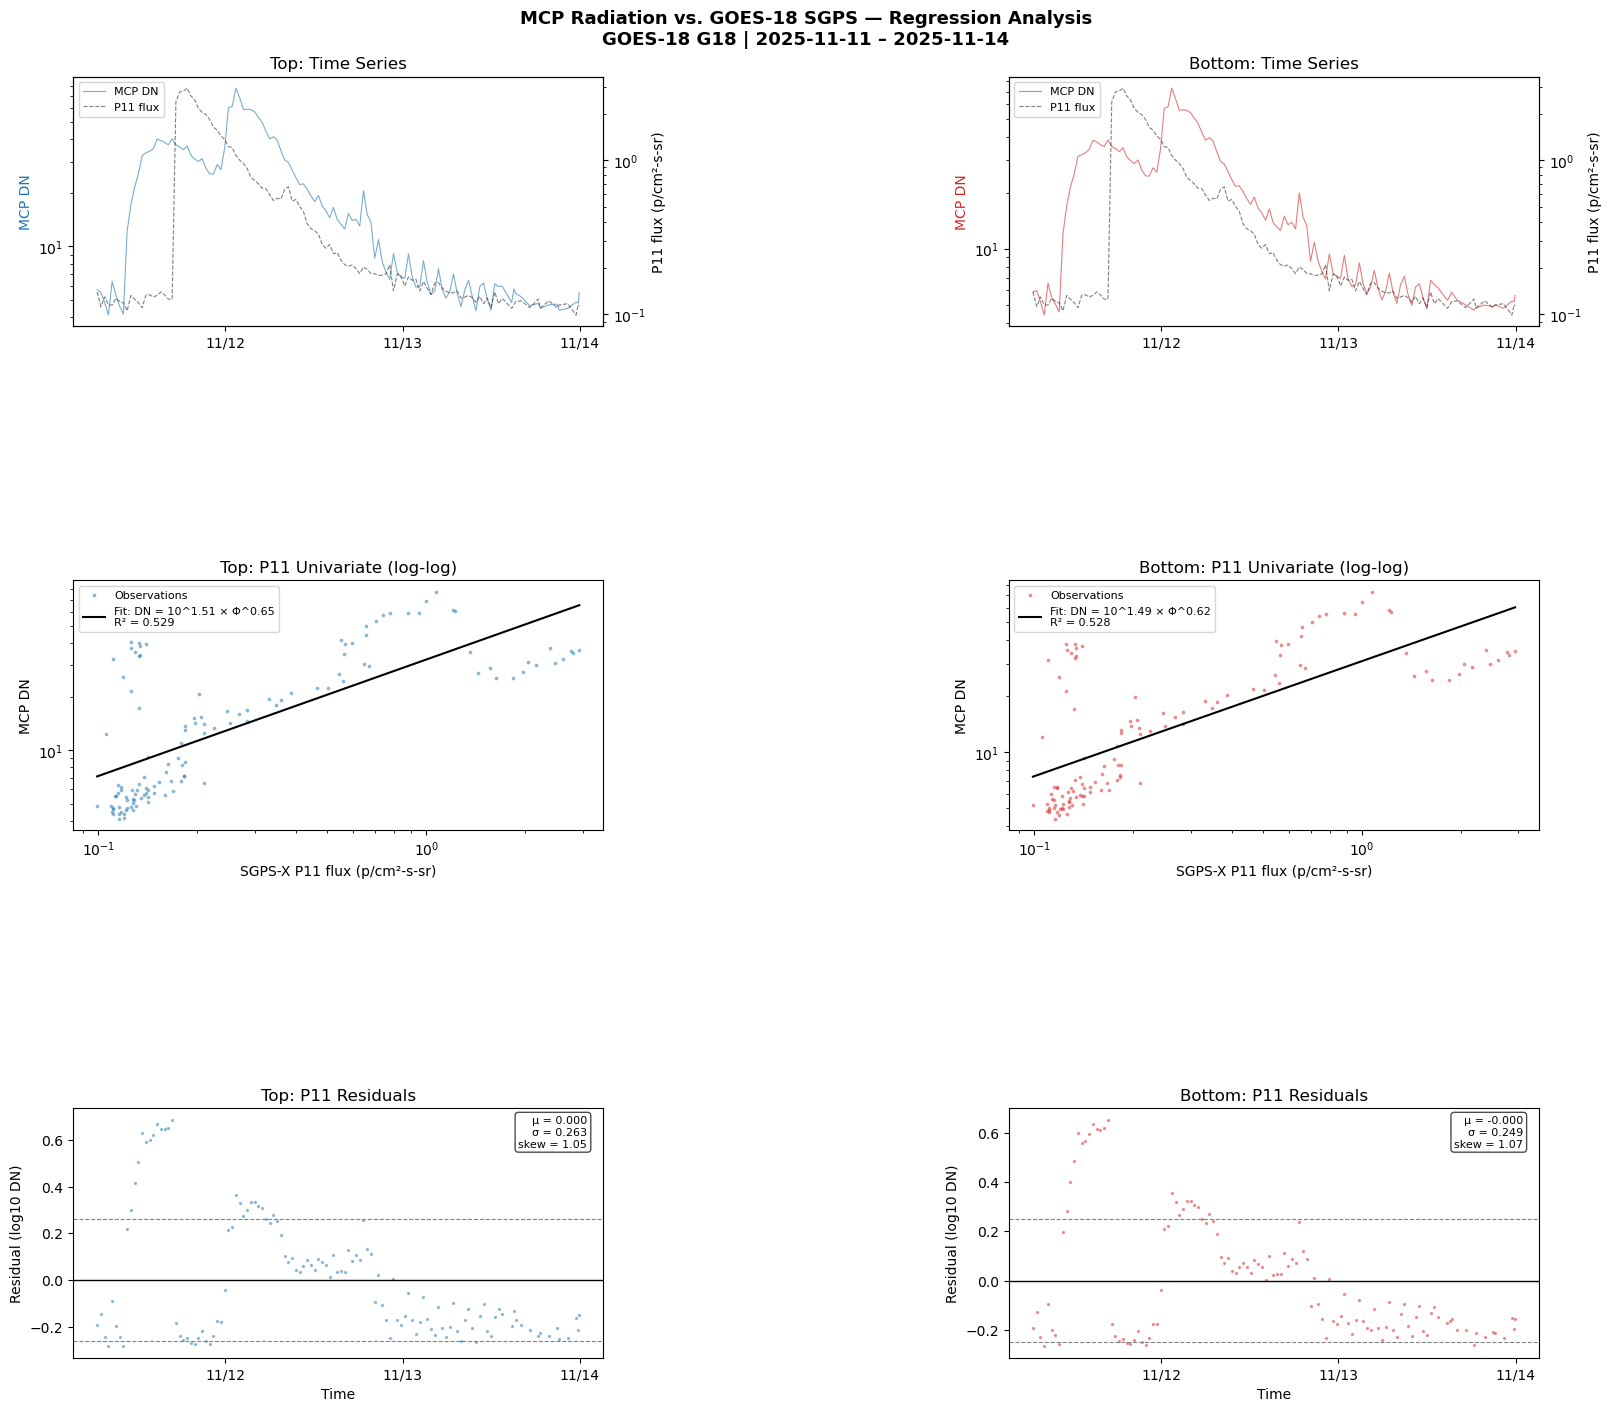

Figure saved to products/mcp_regression_multivariate.png


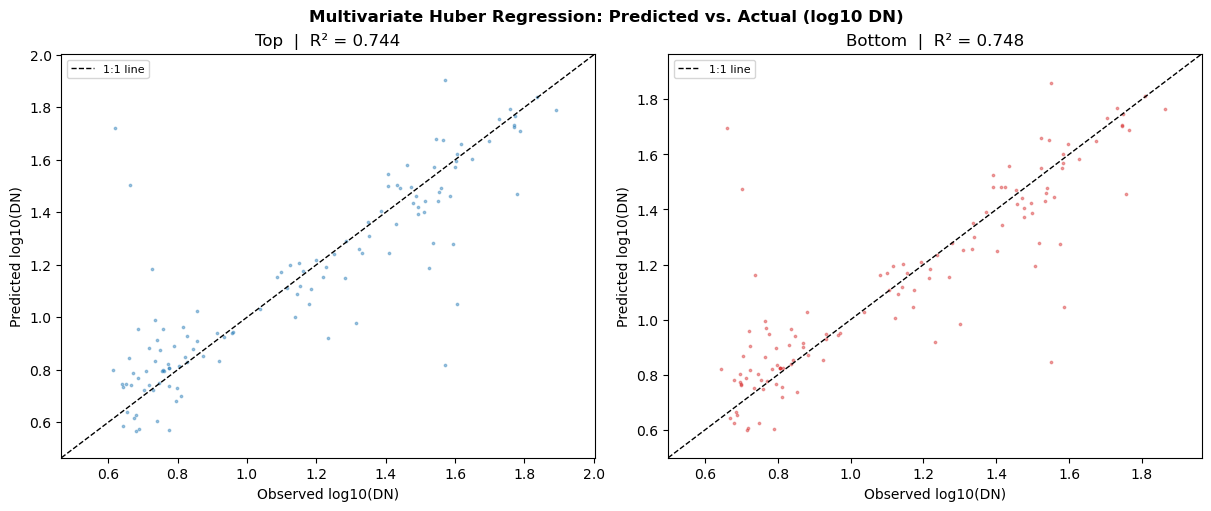


  REGRESSION SUMMARY
  Sensor     Model                         R²    RMSE (log10)
  ---------- ------------------------- ------  --------------
  Top        P11 univariate             0.529          0.2630
  Top        Multivariate (Huber)       0.744          0.1939
  Bottom     P11 univariate             0.528          0.2492
  Bottom     Multivariate (Huber)       0.748          0.1819



In [4]:
"""
mcp_goes18_regression.py
------------------------
Regression analysis: MCP radiation (DN) as a function of GOES-18 SGPS proton flux.
Designed to run after the SGPS plotting script, which leaves the following variables
in scope:
    time                    : np.ndarray of datetime objects (GOES-18 L2 5-min cadence)
    proton_diff_flux_west   : np.ma.MaskedArray, shape (N, 13) [SGPS-X]
    proton_diff_flux_east   : np.ma.MaskedArray, shape (N, 13) [SGPS+X]
    proton_int_flux         : np.ma.MaskedArray, shape (N, 2)  [col 0 = west, col 1 = east]

Both radiation_data-top.nc and radiation_data-bottom.nc are loaded fresh here.

Channel selection notes (per GOES-18 SGPS Full Maturity README, 2023-09-13):
    EXCLUDED:
      SGPS+X (east) P8C [idx 10], P9 [idx 11], P10 [idx 12]  -- temp-dependent ±30%
      SGPS-X (west) P8C [idx 10], P9 [idx 11]                -- factor 2-3 high
      SGPS+X (east) P10 [idx 12]                             -- no response in SEP events
      P5 [idx 5] (both)                                      -- electron contamination
    USED:
      SGPS-X (west)  : P1-P4 [0:4], P6-P7 [6:8], P8A [8], P8B [9]  (T1+T2, well-validated)
      SGPS+X (east)  : P1-P4 [0:4], P6-P7 [6:8], P8A [8], P8B [9]
      P11 integral   : SGPS-X only [col 0]                           (best GCR channel)
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# =============================================================================
# 0. CHANNEL CONFIGURATION (README-informed)
# =============================================================================

CHAN_LABELS = [
    'P1 (1.0-1.9 MeV)',   'P2A (1.9-2.3 MeV)', 'P2B (2.3-3.4 MeV)',
    'P3 (3.4-6.5 MeV)',   'P4 (6.5-12 MeV)',    'P5 (12-25 MeV)',
    'P6 (25-40 MeV)',      'P7 (40-80 MeV)',      'P8A (83-99 MeV)',
    'P8B (99-118 MeV)',    'P8C (118-150 MeV)',   'P9 (150-275 MeV)',
    'P10 (275-500 MeV)',
]

# Indices of usable differential channels per README caveats
WEST_GOOD_DIFF = [0, 1, 2, 3, 4, 6, 7, 8, 9]   # excludes P5[5], P8C[10], P9[11] (factor 2-3 high)
EAST_GOOD_DIFF = [0, 1, 2, 3, 4, 6, 7, 8, 9]   # excludes P5[5], P8C[10], P9[11], P10[12]

# Feature labels for regression output
FEATURE_LABELS_WEST = [f"W_{CHAN_LABELS[i]}" for i in WEST_GOOD_DIFF]
FEATURE_LABELS_EAST = [f"E_{CHAN_LABELS[i]}" for i in EAST_GOOD_DIFF]
FEATURE_LABELS_ALL  = FEATURE_LABELS_WEST + FEATURE_LABELS_EAST + ["P11_west (>500 MeV)"]


# =============================================================================
# 1. HELPER FUNCTIONS
# =============================================================================

def load_radiation_dataset(nc_path, start_dt_str, end_dt_str, n_frames_min=0):
    """Load and filter a Carruthers MCP radiation NetCDF dataset."""
    ds = xr.open_dataset(nc_path)
    mcp_rads  = ds["mcp_rad"].values
    datetimes = ds["observation"].values.astype("datetime64[ns]")
    n_frames  = ds["n_frames"].values
    ds.close()

    start = np.datetime64(start_dt_str)
    end   = np.datetime64(end_dt_str)
    mask  = (datetimes >= start) & (datetimes <= end) & (n_frames >= n_frames_min)

    return datetimes[mask], mcp_rads[mask]


def dt_to_numeric(dt_array):
    """Convert datetime64 or Python datetime array to float seconds since first element."""
    dt64 = np.array(dt_array, dtype="datetime64[ns]")
    return (dt64 - dt64[0]).astype(np.float64) * 1e-9   # nanoseconds → seconds


def interpolate_goes_to_mcp(goes_time, goes_flux_2d, mcp_time):
    """
    Linearly interpolate each GOES-18 flux channel (columns of goes_flux_2d)
    onto the MCP observation timestamps.  NaN-safe: intervals with NaN on
    either bounding point are returned as NaN.

    Parameters
    ----------
    goes_time    : array-like of datetime objects, length N
    goes_flux_2d : (N, C) array of flux values (NaN for bad data)
    mcp_time     : array-like of datetime64[ns], length M

    Returns
    -------
    interp_flux  : (M, C) float array
    """
    goes_t_s = dt_to_numeric(np.array(goes_time, dtype="datetime64[ns]"))
    mcp_t_s  = dt_to_numeric(mcp_time)

    n_chan = goes_flux_2d.shape[1]
    out    = np.full((len(mcp_time), n_chan), np.nan)

    for c in range(n_chan):
        col  = np.asarray(goes_flux_2d[:, c], dtype=float)
        # Build valid-only arrays for interpolation
        valid = np.isfinite(col)
        if valid.sum() < 2:
            continue
        out[:, c] = np.interp(mcp_t_s, goes_t_s[valid], col[valid],
                               left=np.nan, right=np.nan)
    return out


def build_feature_matrix(goes_time, diff_west, diff_east, int_flux, mcp_time):
    """
    Interpolate selected GOES-18 channels to MCP timestamps and assemble
    a feature matrix X of shape (M, n_features).
    """
    # Select good channels
    west_sel = diff_west[:, WEST_GOOD_DIFF]
    east_sel = diff_east[:, EAST_GOOD_DIFF]
    p11_west = int_flux[:, 0:1]   # SGPS-X P11 only

    # Interpolate everything to MCP times
    X_west = interpolate_goes_to_mcp(goes_time, west_sel,  mcp_time)
    X_east = interpolate_goes_to_mcp(goes_time, east_sel,  mcp_time)
    X_p11  = interpolate_goes_to_mcp(goes_time, p11_west,  mcp_time)

    return np.hstack([X_west, X_east, X_p11])   # (M, n_features)


def log_transform(X, y):
    """
    Take log10 of X and y.  Rows where any value is non-positive or NaN are
    dropped. Returns (X_log, y_log, valid_mask).
    """
    valid = np.isfinite(y) & (y > 0)
    valid &= np.all(np.isfinite(X) & (X > 0), axis=1)
    return np.log10(X[valid]), np.log10(y[valid]), valid


def regression_report(name, y_true_log, y_pred_log, feature_names=None, coefs=None):
    """Print a tidy regression summary to stdout."""
    residuals = y_true_log - y_pred_log
    r2  = r2_score(y_true_log, y_pred_log)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  N points : {len(y_true_log)}")
    print(f"  R²       : {r2:.4f}")
    print(f"  RMSE (log10 DN) : {rmse:.4f}  ({10**rmse:.2f}× in linear space)")
    if coefs is not None and feature_names is not None:
        print(f"\n  Coefficients (log10 space):")
        for fn, c in zip(feature_names, coefs):
            print(f"    {fn:<35s} : {c:+.4f}")
    print()


# =============================================================================
# 2. LOAD RADIATION DATA
# =============================================================================

START = "2025-11-11T00:00:00"
END   = "2025-11-14T00:00:00"
N_FRAMES_MIN = 0

print("Loading MCP radiation data...")
dt_top,    dn_top    = load_radiation_dataset("products/radiation_data-top.nc",
                                               START, END, N_FRAMES_MIN)
dt_bottom, dn_bottom = load_radiation_dataset("products/radiation_data-bottom.nc",
                                               START, END, N_FRAMES_MIN)

print(f"  Top    : {len(dn_top)} observations")
print(f"  Bottom : {len(dn_bottom)} observations")


# =============================================================================
# 3. BUILD FEATURE MATRICES (interpolated GOES-18 → MCP timestamps)
# =============================================================================

print("\nInterpolating GOES-18 channels to MCP timestamps...")

X_top    = build_feature_matrix(time, proton_diff_flux_west, proton_diff_flux_east,
                                  proton_int_flux, dt_top)
X_bottom = build_feature_matrix(time, proton_diff_flux_west, proton_diff_flux_east,
                                  proton_int_flux, dt_bottom)

# P11-only feature (last column) for univariate model
P11_COL = -1


# =============================================================================
# 4. REGRESSION — UNIVARIATE (P11 only)
# =============================================================================
# P11 is the best-behaved quiet-time GCR channel and anchors both ends of
# the calibration curve.  A log-log regression tests the power-law hypothesis:
#   DN/s  ∝  Φ^α   →   log(DN) = α·log(Φ) + β

results = {}

for label, dt_arr, dn_arr, X_mat in [
        ("Top",    dt_top,    dn_top,    X_top),
        ("Bottom", dt_bottom, dn_bottom, X_bottom)]:

    print(f"\n--- Sensor: {label} ---")

    # ---- 4a. Univariate: P11 only ----
    X_p11_col = X_mat[:, -1:]
    X_p11_log, y_log, mask_p11 = log_transform(X_p11_col, dn_arr)

    slope, intercept, r_val, p_val, stderr = stats.linregress(
        X_p11_log[:, 0], y_log)
    y_pred_p11 = slope * X_p11_log[:, 0] + intercept

    regression_report(
        f"{label} — Univariate (P11 >500 MeV)",
        y_log, y_pred_p11,
        feature_names=["log10(P11_west)"],
        coefs=[slope]
    )
    print(f"  Power law: DN = 10^({intercept:.3f}) × Φ_P11^({slope:.3f})")

    # ---- 4b. Multivariate: all good channels ----
    X_all_log, y_all_log, mask_all = log_transform(X_mat, dn_arr)

    if X_all_log.shape[0] > X_all_log.shape[1] + 5:
        # Use Huber regression (robust to outliers from particle hit spikes)
        huber = HuberRegressor(epsilon=1.5, max_iter=500)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all_log)
        huber.fit(X_scaled, y_all_log)
        y_pred_multi = huber.predict(X_scaled)

        # Recover unscaled coefficients for interpretability
        raw_coefs = huber.coef_ / scaler.scale_

        regression_report(
            f"{label} — Multivariate (all valid channels, Huber)",
            y_all_log, y_pred_multi,
            feature_names=FEATURE_LABELS_ALL,
            coefs=raw_coefs
        )
    else:
        print(f"  [!] Insufficient valid points for multivariate regression on {label}")
        huber = None

    # Store for plotting
    results[label] = {
        "dt":           dt_arr,
        "dn":           dn_arr,
        "X":            X_mat,
        "mask_p11":     mask_p11,
        "X_p11_log":    X_p11_log,
        "y_log_p11":    y_log,
        "y_pred_p11":   y_pred_p11,
        "slope_p11":    slope,
        "intercept_p11": intercept,
        "r2_p11":       r_val**2,
        "mask_all":     mask_all,
        "y_all_log":    y_all_log,
        "y_pred_multi": y_pred_multi if huber is not None else None,
        "r2_multi":     r2_score(y_all_log, y_pred_multi) if huber is not None else None,
        "huber":        huber,
        "scaler":       scaler if huber is not None else None,
    }


# =============================================================================
# 5. RESIDUAL DIAGNOSTICS
# =============================================================================

for label, res in results.items():
    resid_p11  = res["y_log_p11"] - res["y_pred_p11"]
    times_p11  = res["dt"][res["mask_p11"]]

    print(f"\n{label} P11 residuals:")
    print(f"  Mean  : {resid_p11.mean():.4f} log10-DN")
    print(f"  Std   : {resid_p11.std():.4f} log10-DN  ({10**resid_p11.std():.2f}× in linear)")
    print(f"  Skew  : {stats.skew(resid_p11):.3f}  (>0 → positive outliers from particle hits)")
    print(f"  Kurt  : {stats.kurtosis(resid_p11):.3f}  (>3 → heavy tails)")

    if res["y_pred_multi"] is not None:
        resid_multi = res["y_all_log"] - res["y_pred_multi"]
        print(f"\n{label} Multivariate residuals:")
        print(f"  Mean  : {resid_multi.mean():.4f}")
        print(f"  Std   : {resid_multi.std():.4f}  ({10**resid_multi.std():.2f}× in linear)")


# =============================================================================
# 6. PLOTTING
# =============================================================================

fig = plt.figure(figsize=(16, 14), layout="constrained")
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {"Top": "#1f77b4", "Bottom": "#d62728"}

for col_idx, (label, res) in enumerate(results.items()):
    color = COLORS[label]

    # ---- Panel (row 0): Time series overlay ----
    ax_ts = fig.add_subplot(gs[0, col_idx])

    # Plot P11 on primary y-axis
    goes_t_numeric = dt_to_numeric(np.array(time, dtype="datetime64[ns]"))
    mcp_t_numeric  = dt_to_numeric(res["dt"])
    p11_on_mcp     = np.interp(mcp_t_numeric,
                                goes_t_numeric,
                                np.asarray(proton_int_flux[:, 0], dtype=float),
                                left=np.nan, right=np.nan)

    ax_ts2 = ax_ts.twinx()
    ax_ts.plot(res["dt"], res["dn"], color=color, alpha=0.6, lw=0.8, label="MCP DN")
    ax_ts2.plot(res["dt"], p11_on_mcp, color="k", alpha=0.5, lw=0.8, ls="--", label="P11 flux")
    ax_ts.set_yscale("log")
    ax_ts2.set_yscale("log")
    ax_ts.set_ylabel("MCP DN", color=color)
    ax_ts2.set_ylabel("P11 flux (p/cm²-s-sr)", color="k")
    ax_ts.set_title(f"{label}: Time Series")
    ax_ts.xaxis.set_major_locator(mdates.DayLocator())
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    lines1, labs1 = ax_ts.get_legend_handles_labels()
    lines2, labs2 = ax_ts2.get_legend_handles_labels()
    ax_ts.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper left")

    # ---- Panel (row 1): Log-log scatter + P11 fit ----
    ax_sc = fig.add_subplot(gs[1, col_idx])

    ax_sc.scatter(10**res["X_p11_log"][:, 0], 10**res["y_log_p11"],
                  s=3, alpha=0.4, color=color, label="Observations")

    # Overplot power-law fit line
    x_fit = np.logspace(np.nanmin(res["X_p11_log"]),
                         np.nanmax(res["X_p11_log"]), 200)
    y_fit = 10**(res["slope_p11"] * np.log10(x_fit) + res["intercept_p11"])
    ax_sc.plot(x_fit, y_fit, color="k", lw=1.5,
               label=f"Fit: DN = 10^{res['intercept_p11']:.2f} × Φ^{res['slope_p11']:.2f}\n"
                     f"R² = {res['r2_p11']:.3f}")

    ax_sc.set_xscale("log")
    ax_sc.set_yscale("log")
    ax_sc.set_xlabel("SGPS-X P11 flux (p/cm²-s-sr)")
    ax_sc.set_ylabel("MCP DN")
    ax_sc.set_title(f"{label}: P11 Univariate (log-log)")
    ax_sc.legend(fontsize=8)

    # ---- Panel (row 2): Residual time series (P11 model) ----
    ax_res = fig.add_subplot(gs[2, col_idx])
    resid  = res["y_log_p11"] - res["y_pred_p11"]
    times_p11 = res["dt"][res["mask_p11"]]

    ax_res.scatter(times_p11, resid, s=2, alpha=0.4, color=color)
    ax_res.axhline(0,  color="k",    lw=1.0, ls="-")
    ax_res.axhline(+resid.std(),  color="grey", lw=0.8, ls="--")
    ax_res.axhline(-resid.std(),  color="grey", lw=0.8, ls="--")
    ax_res.set_xlabel("Time")
    ax_res.set_ylabel("Residual (log10 DN)")
    ax_res.set_title(f"{label}: P11 Residuals")
    ax_res.xaxis.set_major_locator(mdates.DayLocator())
    ax_res.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

    # Annotate with residual statistics
    ann = (f"μ = {resid.mean():.3f}\nσ = {resid.std():.3f}\n"
           f"skew = {stats.skew(resid):.2f}")
    ax_res.text(0.97, 0.97, ann, transform=ax_res.transAxes,
                fontsize=8, va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

fig.suptitle("MCP Radiation vs. GOES-18 SGPS — Regression Analysis\n"
             "GOES-18 G18 | 2025-11-11 – 2025-11-14", fontsize=13, fontweight="bold")

plt.savefig("products/mcp_regression_analysis.png", dpi=150, bbox_inches="tight")
print("\nFigure saved to products/mcp_regression_analysis.png")
plt.show()


# =============================================================================
# 7. MULTIVARIATE PREDICTED vs. ACTUAL (separate figure if models exist)
# =============================================================================

any_multi = any(res["y_pred_multi"] is not None for res in results.values())
if any_multi:
    fig2, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
    fig2.suptitle("Multivariate Huber Regression: Predicted vs. Actual (log10 DN)",
                  fontsize=12, fontweight="bold")

    for ax, (label, res) in zip(axes, results.items()):
        if res["y_pred_multi"] is None:
            ax.set_visible(False)
            continue
        color = COLORS[label]
        y_true = res["y_all_log"]
        y_pred = res["y_pred_multi"]

        lims = [min(y_true.min(), y_pred.min()) - 0.1,
                max(y_true.max(), y_pred.max()) + 0.1]
        ax.scatter(y_true, y_pred, s=3, alpha=0.4, color=color)
        ax.plot(lims, lims, "k--", lw=1, label="1:1 line")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Observed log10(DN)")
        ax.set_ylabel("Predicted log10(DN)")
        ax.set_title(f"{label}  |  R² = {res['r2_multi']:.3f}")
        ax.legend(fontsize=8)

    plt.savefig("products/mcp_regression_multivariate.png", dpi=150, bbox_inches="tight")
    print("Figure saved to products/mcp_regression_multivariate.png")
    plt.show()


# =============================================================================
# 8. SUMMARY TABLE
# =============================================================================

print("\n" + "="*60)
print("  REGRESSION SUMMARY")
print("="*60)
print(f"  {'Sensor':<10} {'Model':<25} {'R²':>6}  {'RMSE (log10)':>14}")
print(f"  {'-'*10} {'-'*25} {'-'*6}  {'-'*14}")

for label, res in results.items():
    rmse_p11 = np.sqrt(np.mean((res["y_log_p11"] - res["y_pred_p11"])**2))
    print(f"  {label:<10} {'P11 univariate':<25} {res['r2_p11']:>6.3f}  {rmse_p11:>14.4f}")
    if res["r2_multi"] is not None:
        rmse_m = np.sqrt(np.mean((res["y_all_log"] - res["y_pred_multi"])**2))
        print(f"  {label:<10} {'Multivariate (Huber)':<25} {res['r2_multi']:>6.3f}  {rmse_m:>14.4f}")

print()